<a href="https://colab.research.google.com/github/Harshit10880/Chat-logger/blob/main/retail_house.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn import tree
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import svm
# from sklearn import tree
df = pd.read_csv('retail_practice_data_cleaned.csv')

In [ ]:
print(df.head())

  Transaction_ID        Date Customer_ID Product_Category  Quantity  \
0          T2000  2026-01-01       C8270      Electronics         2   
1          T2001  2026-01-01       C1860         Clothing         1   
2          T2002  2026-01-01       C6390         Clothing         3   
3          T2003  2026-01-01       C6191          Grocery         6   
4          T2004  2026-01-01       C6734      Electronics         8   

   Unit_Price Payment_Method Return_Status  Customer_Age  Total_Spent  
0      364.90     Debit Card            No     61.000000       729.80  
1      377.09    Credit Card            No     46.727835       377.09  
2       81.50     Debit Card            No     41.000000       244.50  
3       60.37    Credit Card            No     51.000000       362.22  
4      289.74    Credit Card            No     44.000000      2317.92  


# **charts**

Text(0.5, 1.0, 'Identifying Price Outliers')

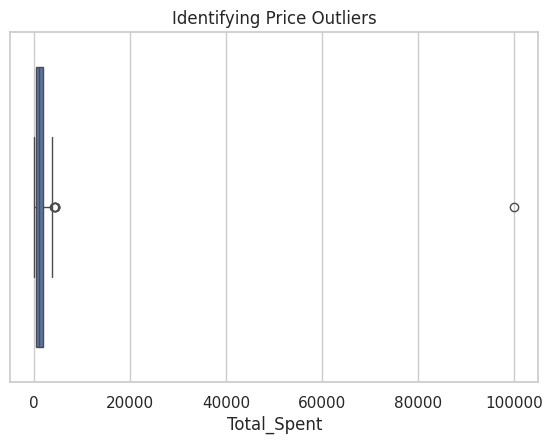

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.boxplot(x=df['Total_Spent'])
plt.title('Identifying Price Outliers')

Text(0.5, 1.0, 'Customer Age Distribution')

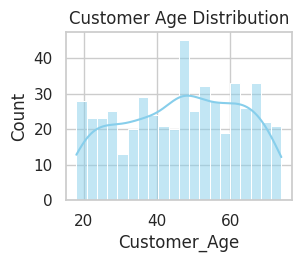

In [ ]:
plt.subplot(2, 2, 2)
sns.histplot(df['Customer_Age'].dropna(), bins=20, kde=True, color='skyblue')
plt.title('Customer Age Distribution')

Text(0.5, 1.0, 'Sales by Product Category')

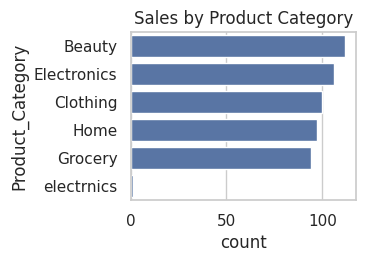

In [ ]:
plt.subplot(2, 2, 3)
sns.countplot(y=df['Product_Category'], order=df['Product_Category'].value_counts().index)
plt.title('Sales by Product Category')

Text(0.5, 1.0, 'Correlation between Numeric Features')

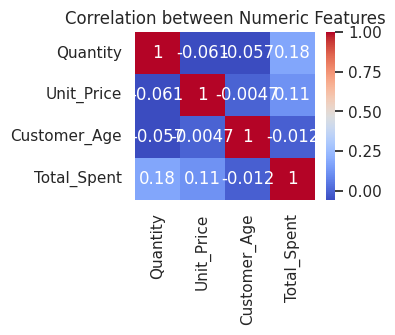

In [ ]:
plt.subplot(2, 2, 4)
# We only use numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between Numeric Features')

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Day'] = df['Date'].dt.date
df['Hour'] = df['Date'].dt.hour

Text(0.5, 1.0, 'Daily Revenue Trend')

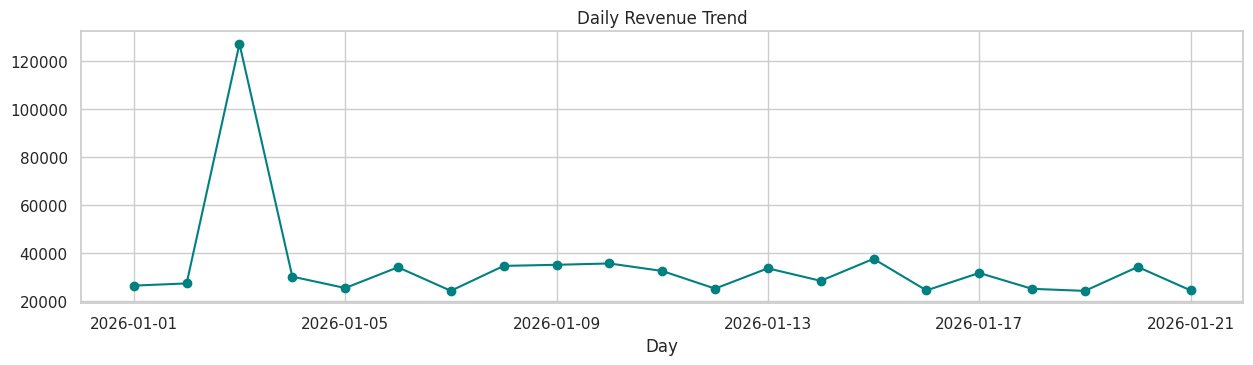

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

# Daily Revenue Line Chart
plt.subplot(3, 1, 1)
daily_rev = df.groupby('Day')['Total_Spent'].sum()
daily_rev.plot(kind='line', marker='o', color='teal')
plt.title('Daily Revenue Trend')

Text(0.5, 1.0, 'Daily Sales Growth Rate (%)')

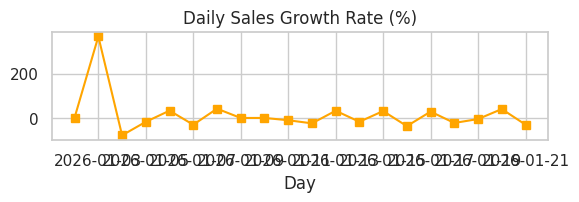

In [ ]:
plt.subplot(3, 1, 2)
daily_rev.pct_change().mul(100).plot(kind='line', marker='s', color='orange')
plt.title('Daily Sales Growth Rate (%)')

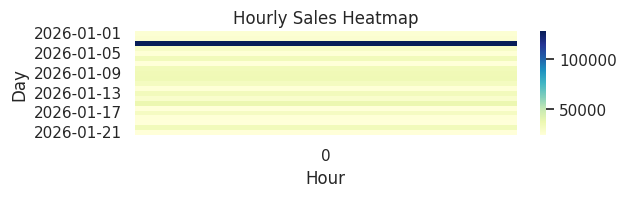

In [ ]:
plt.subplot(3, 1, 3)
hourly_map = df.groupby(['Day', 'Hour'])['Total_Spent'].sum().unstack().fillna(0)
sns.heatmap(hourly_map, cmap='YlGnBu')
plt.title('Hourly Sales Heatmap')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Total Revenue by Category (Spot the Typos!)')

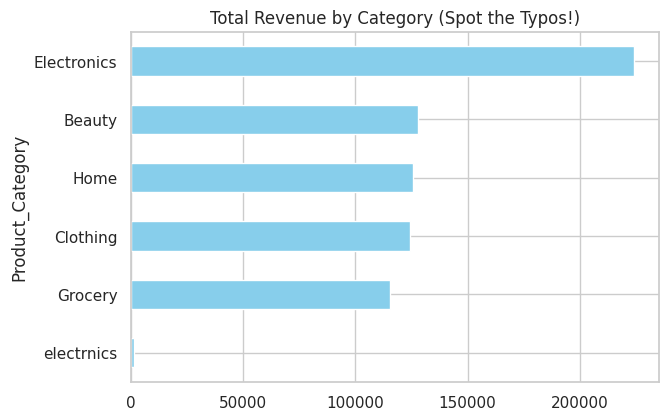

In [ ]:
plt.figure(figsize=(15, 10))

# Revenue Bar Chart
plt.subplot(2, 2, 1)
df.groupby('Product_Category')['Total_Spent'].sum().sort_values().plot(kind='barh', color='skyblue')
plt.title('Total Revenue by Category (Spot the Typos!)')

Text(0.5, 1.0, 'Avg Unit Price per Category')

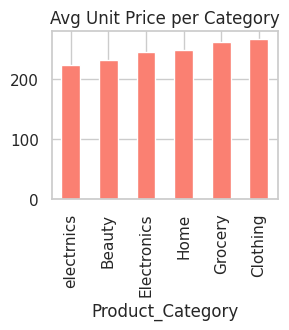

In [ ]:
plt.subplot(2, 2, 2)
df.groupby('Product_Category')['Unit_Price'].mean().sort_values().plot(kind='bar', color='salmon')
plt.title('Avg Unit Price per Category')

Text(0.5, 1.0, 'Return Rate (%) by Category')

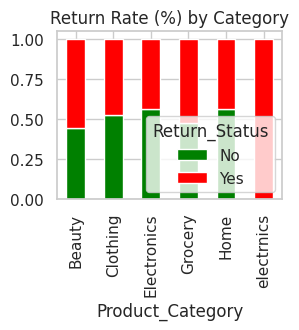

In [ ]:
plt.subplot(2, 2, 3)
pd.crosstab(df['Product_Category'], df['Return_Status'], normalize='index').plot(kind='bar', stacked=True, ax=plt.gca(), color=['green', 'red'])
plt.title('Return Rate (%) by Category')


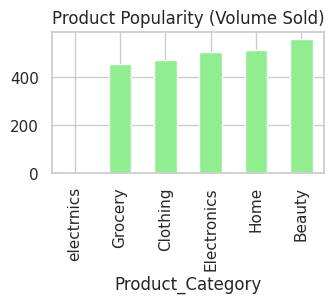

In [ ]:
plt.subplot(2, 2, 4)
df.groupby('Product_Category')['Quantity'].sum().sort_values().plot(kind='bar', color='lightgreen')
plt.title('Product Popularity (Volume Sold)')
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Customer Age Distribution')

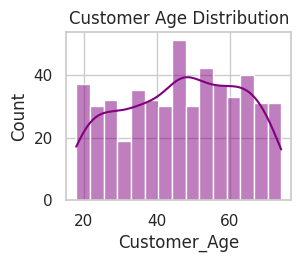

In [ ]:
plt.subplot(2, 2, 1)
sns.histplot(df['Customer_Age'].dropna(), bins=15, kde=True, color='purple')
plt.title('Customer Age Distribution')

Text(0.5, 1.0, 'Total Spent Boxplot (Finding Anomalies)')

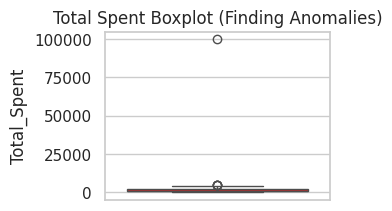

In [ ]:
plt.subplot(2, 2, 2)
sns.boxplot(y=df['Total_Spent'], color='red')
plt.title('Total Spent Boxplot (Finding Anomalies)')

Text(0.5, 1.0, 'Quantity vs Total Spent (Logic Check)')

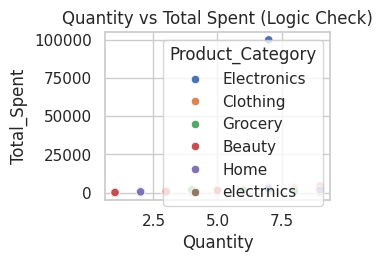

In [ ]:
plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='Quantity', y='Total_Spent', hue='Product_Category')
plt.title('Quantity vs Total Spent (Logic Check)')

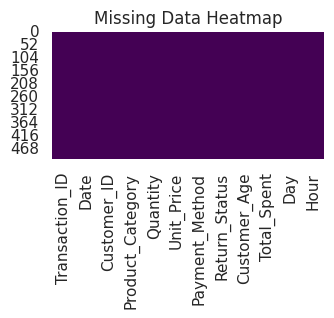

In [ ]:
plt.subplot(2, 2, 4)
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Return Status by Payment Method')

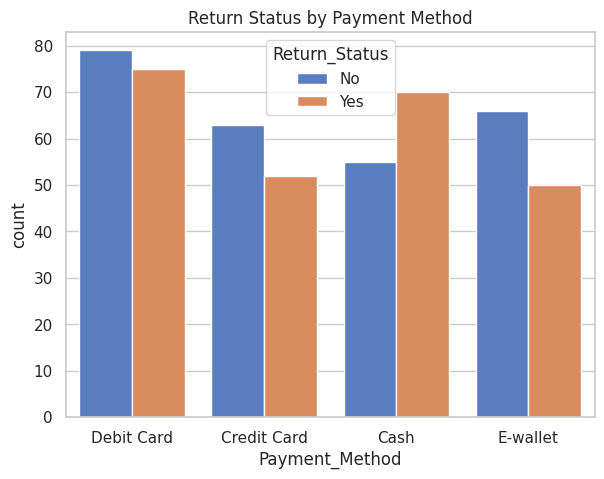

In [ ]:
plt.figure(figsize=(15, 5))

# Return Status vs Payment Method
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Payment_Method', hue='Return_Status', palette='muted')
plt.title('Return Status by Payment Method')

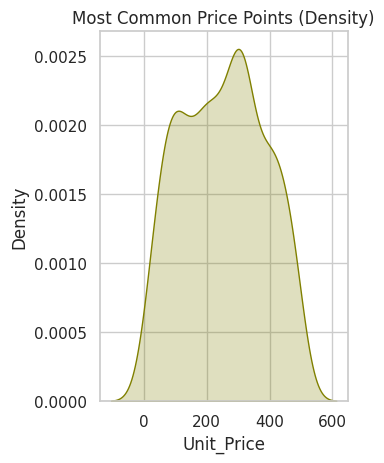

In [ ]:
plt.subplot(1, 2, 2)
sns.kdeplot(df['Unit_Price'], fill=True, color='olive')
plt.title('Most Common Price Points (Density)')
plt.tight_layout()
plt.show()

# **coding**

In [ ]:
df.head()

,Transaction_ID,Date,Customer_ID,Product_Category,Quantity,Unit_Price,Payment_Method,Return_Status,Customer_Age,Total_Spent,Day,Hour
0,T2000,2026-01-01,C8270,Electronics,2,364.90,Debit Card,No,61.000000,729.80,2026-01-01,0
1,T2001,2026-01-01,C1860,Clothing,1,377.09,Credit Card,No,46.727835,377.09,2026-01-01,0
2,T2002,2026-01-01,C6390,Clothing,3,81.50,Debit Card,No,41.000000,244.50,2026-01-01,0
3,T2003,2026-01-01,C6191,Grocery,6,60.37,Credit Card,No,51.000000,362.22,2026-01-01,0
4,T2004,2026-01-01,C6734,Electronics,8,289.74,Credit Card,No,44.000000,2317.92,2026-01-01,0


In [ ]:
scaler = StandardScaler()
# Formula applied: z = (x - mean) / std_dev
df['Age_Standardized'] = scaler.fit_transform(df[['Customer_Age']])

# 4. Check the results
# print(df[['Customer_Age', 'Age_Standardized']].head())
pd.options.display.float_format = '{:.4f}'.format
print(df[['Customer_Age', 'Age_Standardized']].head())

   Customer_Age  Age_Standardized
0       61.0000            0.8962
1       46.7278           -0.0000
2       41.0000           -0.3597
3       51.0000            0.2683
4       44.0000           -0.1713


In [ ]:
df.head()

,Transaction_ID,Date,Customer_ID,Product_Category,Quantity,Unit_Price,Payment_Method,Return_Status,Customer_Age,Total_Spent,Day,Hour,Age_Standardized
0,T2000,2026-01-01,C8270,Electronics,2,364.9000,Debit Card,No,61.0000,729.8000,2026-01-01,0,0.8962
1,T2001,2026-01-01,C1860,Clothing,1,377.0900,Credit Card,No,46.7278,377.0900,2026-01-01,0,-0.0000
2,T2002,2026-01-01,C6390,Clothing,3,81.5000,Debit Card,No,41.0000,244.5000,2026-01-01,0,-0.3597
3,T2003,2026-01-01,C6191,Grocery,6,60.3700,Credit Card,No,51.0000,362.2200,2026-01-01,0,0.2683
4,T2004,2026-01-01,C6734,Electronics,8,289.7400,Credit Card,No,44.0000,2317.9200,2026-01-01,0,-0.1713


In [ ]:
df = pd.get_dummies(df, columns=['Payment_Method'], prefix='Pay', dtype=int)
print(df[['Pay_Cash', 'Pay_Credit Card', 'Pay_Debit Card', 'Pay_E-wallet']].head())

   Pay_Cash  Pay_Credit Card  Pay_Debit Card  Pay_E-wallet
0         0                0               1             0
1         0                1               0             0
2         0                0               1             0
3         0                1               0             0
4         0                1               0             0


In [ ]:
df.head()

,Transaction_ID,Date,Customer_ID,Product_Category,Quantity,Unit_Price,Return_Status,Customer_Age,Total_Spent,Day,Hour,Age_Standardized,Pay_Cash,Pay_Credit Card,Pay_Debit Card,Pay_E-wallet
0,T2000,2026-01-01,C8270,Electronics,2,364.9000,No,61.0000,729.8000,2026-01-01,0,0.8962,0,0,1,0
1,T2001,2026-01-01,C1860,Clothing,1,377.0900,No,46.7278,377.0900,2026-01-01,0,-0.0000,0,1,0,0
2,T2002,2026-01-01,C6390,Clothing,3,81.5000,No,41.0000,244.5000,2026-01-01,0,-0.3597,0,0,1,0
3,T2003,2026-01-01,C6191,Grocery,6,60.3700,No,51.0000,362.2200,2026-01-01,0,0.2683,0,1,0,0
4,T2004,2026-01-01,C6734,Electronics,8,289.7400,No,44.0000,2317.9200,2026-01-01,0,-0.1713,0,1,0,0


In [ ]:
df['Product_Category'] = df['Product_Category'].replace('electrnics', 'Electronics')
df = pd.get_dummies(df, columns=['Product_Category'], prefix='Cat', dtype=int)

In [ ]:
df.head()

,Transaction_ID,Date,Customer_ID,Quantity,Unit_Price,Return_Status,Customer_Age,Total_Spent,Day,Hour,Age_Standardized,Pay_Cash,Pay_Credit Card,Pay_Debit Card,Pay_E-wallet,Cat_Beauty,Cat_Clothing,Cat_Electronics,Cat_Grocery,Cat_Home
0,T2000,2026-01-01,C8270,2,364.9000,No,61.0000,729.8000,2026-01-01,0,0.8962,0,0,1,0,0,0,1,0,0
1,T2001,2026-01-01,C1860,1,377.0900,No,46.7278,377.0900,2026-01-01,0,-0.0000,0,1,0,0,0,1,0,0,0
2,T2002,2026-01-01,C6390,3,81.5000,No,41.0000,244.5000,2026-01-01,0,-0.3597,0,0,1,0,0,1,0,0,0
3,T2003,2026-01-01,C6191,6,60.3700,No,51.0000,362.2200,2026-01-01,0,0.2683,0,1,0,0,0,0,0,1,0
4,T2004,2026-01-01,C6734,8,289.7400,No,44.0000,2317.9200,2026-01-01,0,-0.1713,0,1,0,0,0,0,1,0,0


In [ ]:
df['Return_Status'] = df['Return_Status'].map({'Yes': 1, 'No': 0})

In [ ]:
df.head()

,Transaction_ID,Date,Customer_ID,Quantity,Unit_Price,Return_Status,Customer_Age,Total_Spent,Day,Hour,Age_Standardized,Pay_Cash,Pay_Credit Card,Pay_Debit Card,Pay_E-wallet,Cat_Beauty,Cat_Clothing,Cat_Electronics,Cat_Grocery,Cat_Home
0,T2000,2026-01-01,C8270,2,364.9000,0,61.0000,729.8000,2026-01-01,0,0.8962,0,0,1,0,0,0,1,0,0
1,T2001,2026-01-01,C1860,1,377.0900,0,46.7278,377.0900,2026-01-01,0,-0.0000,0,1,0,0,0,1,0,0,0
2,T2002,2026-01-01,C6390,3,81.5000,0,41.0000,244.5000,2026-01-01,0,-0.3597,0,0,1,0,0,1,0,0,0
3,T2003,2026-01-01,C6191,6,60.3700,0,51.0000,362.2200,2026-01-01,0,0.2683,0,1,0,0,0,0,0,1,0
4,T2004,2026-01-01,C6734,8,289.7400,0,44.0000,2317.9200,2026-01-01,0,-0.1713,0,1,0,0,0,0,1,0,0


In [ ]:
feature_columns = ['Customer_Age', 'Quantity', 'Unit_Price',
                   'Pay_Cash', 'Pay_Credit Card', 'Pay_Debit Card', 'Pay_E-wallet',
                   'Cat_Beauty', 'Cat_Clothing', 'Cat_Electronics', 'Cat_Grocery', 'Cat_Home']
X = df[feature_columns]
y = df['Return_Status']

print("X head:")
display(X.head())
print("\ny head:")
display(y.head())

X head:


,Customer_Age,Quantity,Unit_Price,Pay_Cash,Pay_Credit Card,Pay_Debit Card,Pay_E-wallet,Cat_Beauty,Cat_Clothing,Cat_Electronics,Cat_Grocery,Cat_Home
0,61.0000,2,364.9000,0,0,1,0,0,0,1,0,0
1,46.7278,1,377.0900,0,1,0,0,0,1,0,0,0
2,41.0000,3,81.5000,0,0,1,0,0,1,0,0,0
3,51.0000,6,60.3700,0,1,0,0,0,0,0,1,0
4,44.0000,8,289.7400,0,1,0,0,0,0,1,0,0



y head:


,Return_Status
0,0
1,0
2,0
3,0
4,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
predictions = model.predict(X_test_scaled)

In [ ]:
print(f"Model Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%")

Model Accuracy: 46.08%


# **validation & confidence**

In [ ]:
y_pred = model.predict(X_test_scaled)

# 2. Get the probability (Confidence Score between 0 and 1)
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# 3. Create a comparison table
comparison = pd.DataFrame({
    'Actual_Answer': y_test.values,
    'Model_Guess': y_pred,
    'Probability': y_probs
})

# 4. Add a "Success" column to make it easy to read
comparison['Is_Correct'] = (comparison['Actual_Answer'] == comparison['Model_Guess'])

# 5. Print the first 10 rows to see the results
print(comparison.head(10))

   Actual_Answer  Model_Guess  Probability  Is_Correct
0              0            0       0.3945        True
1              1            0       0.4632       False
2              1            0       0.4237       False
3              0            0       0.4907        True
4              1            1       0.5121        True
5              1            1       0.5298        True
6              0            1       0.5398       False
7              0            0       0.4908        True
8              0            1       0.5459       False
9              0            1       0.5699       False


Random forest is only for adding purpose in this project

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize a 'Smarter' Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train it
rf_model.fit(X_train, y_train)

# 3. Check Accuracy
rf_pred = rf_model.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred) * 100:.2f}%")

Random Forest Accuracy: 52.94%


# confusion matrix solution

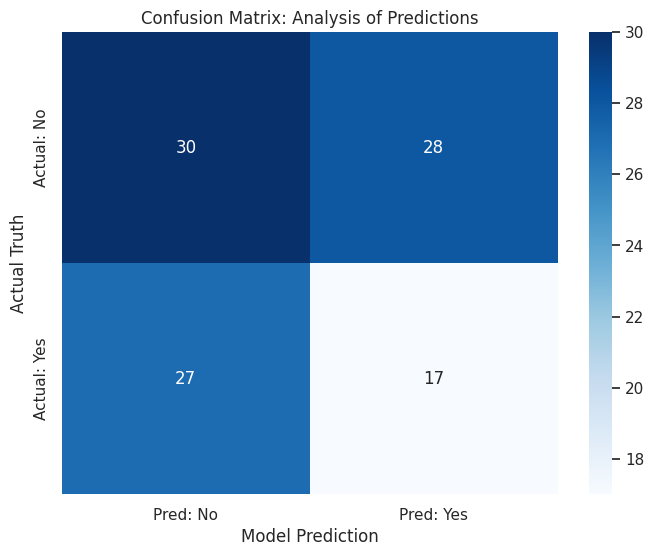

In [ ]:
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No', 'Pred: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])

plt.title('Confusion Matrix: Analysis of Predictions')
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.show()

In [ ]:
df['Price_Per_Unit'] = df['Total_Spent'] / df['Quantity']
df.head()

,Transaction_ID,Date,Customer_ID,Quantity,Unit_Price,Return_Status,Customer_Age,Total_Spent,Day,Hour,...,Pay_Cash,Pay_Credit Card,Pay_Debit Card,Pay_E-wallet,Cat_Beauty,Cat_Clothing,Cat_Electronics,Cat_Grocery,Cat_Home,Price_Per_Unit
0,T2000,2026-01-01,C8270,2,364.9000,0,61.0000,729.8000,2026-01-01,0,...,0,0,1,0,0,0,1,0,0,364.9000
1,T2001,2026-01-01,C1860,1,377.0900,0,46.7278,377.0900,2026-01-01,0,...,0,1,0,0,0,1,0,0,0,377.0900
2,T2002,2026-01-01,C6390,3,81.5000,0,41.0000,244.5000,2026-01-01,0,...,0,0,1,0,0,1,0,0,0,81.5000
3,T2003,2026-01-01,C6191,6,60.3700,0,51.0000,362.2200,2026-01-01,0,...,0,1,0,0,0,0,0,1,0,60.3700
4,T2004,2026-01-01,C6734,8,289.7400,0,44.0000,2317.9200,2026-01-01,0,...,0,1,0,0,0,0,1,0,0,289.7400


In [ ]:
bins = [0, 25, 45, 65, 100]
labels = ['GenZ', 'Millennial', 'GenX', 'Senior']
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=bins, labels=labels)

In [ ]:
df.head()

,Transaction_ID,Date,Customer_ID,Quantity,Unit_Price,Return_Status,Customer_Age,Total_Spent,Day,Hour,...,Pay_Credit Card,Pay_Debit Card,Pay_E-wallet,Cat_Beauty,Cat_Clothing,Cat_Electronics,Cat_Grocery,Cat_Home,Price_Per_Unit,Age_Group
0,T2000,2026-01-01,C8270,2,364.9000,0,61.0000,729.8000,2026-01-01,0,...,0,1,0,0,0,1,0,0,364.9000,GenX
1,T2001,2026-01-01,C1860,1,377.0900,0,46.7278,377.0900,2026-01-01,0,...,1,0,0,0,1,0,0,0,377.0900,GenX
2,T2002,2026-01-01,C6390,3,81.5000,0,41.0000,244.5000,2026-01-01,0,...,0,1,0,0,1,0,0,0,81.5000,Millennial
3,T2003,2026-01-01,C6191,6,60.3700,0,51.0000,362.2200,2026-01-01,0,...,1,0,0,0,0,0,1,0,60.3700,GenX
4,T2004,2026-01-01,C6734,8,289.7400,0,44.0000,2317.9200,2026-01-01,0,...,1,0,0,0,0,1,0,0,289.7400,Millennial


In [ ]:
df['Is_High_Value'] = (df['Total_Spent'] > df['Total_Spent'].mean()).astype(int)

In [ ]:
df_ml = df.copy()
# Apply get_dummies for Age_Group
df_ml = pd.get_dummies(df_ml, columns=['Age_Group'], prefix={'Age_Group':'AgeG'}, dtype=int)

# Return_Status is already numeric from cell 0KJQnD8lGiE3
df_ml['Return_Target'] = df_ml['Return_Status']

In [ ]:
X = df_ml[['Price_Per_Unit', 'Is_High_Value', 'Quantity', 'Cat_Electronics', 'Cat_Clothing']]
y = df_ml['Return_Target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
predictions = model.predict(X_test_scaled)
print(f"Accuracy with Secret Sauce: {accuracy_score(y_test, predictions) * 100:.2f}%")

Accuracy with Secret Sauce: 45.10%


# decision tree

In [ ]:
feature_columns = ['Customer_Age', 'Quantity', 'Unit_Price',
                   'Pay_Cash', 'Pay_Credit Card', 'Pay_Debit Card', 'Pay_E-wallet',
                   'Cat_Beauty', 'Cat_Clothing', 'Cat_Electronics', 'Cat_Grocery', 'Cat_Home']
X = df[feature_columns]
y = df['Return_Status']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# model_dt = tree.DecisionTreeClassifier()


# model_dt = tree.DecisionTreeClassifier(criterion='gini')
# model_dt = tree.DecisionTreeClassifier(criterion='entropy')
model_dt = tree.DecisionTreeClassifier(criterion='log_loss', splitter='best', max_depth=5, min_samples_split=4, min_samples_leaf=2, max_features='sqrt')

# from sklearn.model_selection import GridSearchCV

# model_dt = tree.DecisionTreeClassifier()
# params_dt_1 = {
#     'criterion': ['gini', 'entropy'],
#     'max_depth': [2, 3, 4, 5],
#     'min_samples_split': [2, 4, 6],
#     'min_samples_leaf': [1, 2, 3],
#     'splitter': ['best', 'random']
# }

# grid_dt_1 = GridSearchCV(
#     estimator=model_dt,
#     param_grid=params_dt_1,
#     cv=5
# )

model_dt.fit(X_train_scaled, y_train)
# grid_dt_1.fit(X_train_scaled, y_train)

DecisionTreeClassifier(criterion='log_loss', max_depth=5, max_features='sqrt',
                       min_samples_leaf=2, min_samples_split=4)

In [ ]:
print("Best Parameters:")
print(grid_dt_1.best_params_)

# Best accuracy
print("\nBest Accuracy:")
print(grid_dt_1.best_score_)

Best Parameters:
{'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 6, 'splitter': 'random'}

Best Accuracy:
0.5589581451370069


In [ ]:
pridt_dt = model_dt.predict(X_test_scaled)
print(f"Model Accuracy: {accuracy_score(y_test, pridt_dt) * 100:.2f}%")

Model Accuracy: 55.88%


In [ ]:
joblib.dump(model_dt, "retail_model.joblib")
joblib.dump(scaler, "retail_scaler.joblib")

['retail_scaler.joblib']

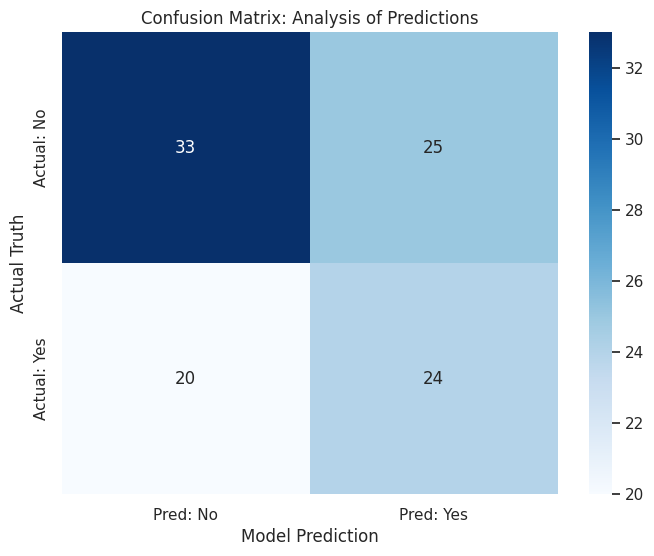

In [ ]:
cm = confusion_matrix(y_test, pridt_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No', 'Pred: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])

plt.title('Confusion Matrix: Analysis of Predictions')
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.show()

In [ ]:
print(classification_report(y_test, pridt_dt))

              precision    recall  f1-score   support

           0       0.62      0.57      0.59        58
           1       0.49      0.55      0.52        44

    accuracy                           0.56       102
   macro avg       0.56      0.56      0.56       102
weighted avg       0.57      0.56      0.56       102



# KNN alforithm

In [ ]:
# model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn = KNeighborsClassifier(n_neighbors=7)
model_knn.fit(X_train_scaled, y_train)

# from sklearn.model_selection import GridSearchCV

# model_knn = KNeighborsClassifier()

# params_2 = {
#      'n_neighbors': [3, 5, 7, 9],
#     'weights': ['uniform', 'distance'],
#     'metric': ['euclidean', 'manhattan'],
#     'p': [1, 2]
# }

# params_3 = {

#     'n_neighbors': list(range(1, 31)),

#     'weights': ['uniform', 'distance'],

#     'metric': [
#         'euclidean',
#         'manhattan',
#         'minkowski',
#         'chebyshev'
#     ],

#     'p': [1, 2, 3],

#     'algorithm': [
#         'auto',
#         'ball_tree',
#         'kd_tree',
#         'brute'
#     ],

#     'leaf_size': [10, 20, 30, 40, 50]
# }

# grid_knn = GridSearchCV(
#     estimator=model_knn,
#     param_grid=params_3,
#     cv=5
# )


# grid_knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=7)

In [ ]:
print("Best K value:", grid_knn.best_params_)

# Print best accuracy
print("Best Accuracy:", grid_knn.best_score_)

In [ ]:
pridt_knn = model_knn.predict(X_test_scaled)
print(f"Model Accuracy: {accuracy_score(y_test, pridt_knn) * 100:.2f}%")

Model Accuracy: 50.98%


In [ ]:
print(classification_report(y_test, pridt_knn))

              precision    recall  f1-score   support

           0       0.58      0.48      0.53        58
           1       0.44      0.55      0.49        44

    accuracy                           0.51       102
   macro avg       0.51      0.51      0.51       102
weighted avg       0.52      0.51      0.51       102



# Naive bayes algorithm

In [ ]:
model_nb = GaussianNB()
model_nb.fit(X_train_scaled, y_train)

GaussianNB()

In [ ]:
pridt_nb = model_nb.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, pridt_nb) * 100:.2f}%")

Model Accuracy: 51.96%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


In [ ]:
print(classification_report(y_test, pridt_nb))

              precision    recall  f1-score   support

           0       0.55      0.86      0.67        58
           1       0.27      0.07      0.11        44

    accuracy                           0.52       102
   macro avg       0.41      0.47      0.39       102
weighted avg       0.43      0.52      0.43       102



In [ ]:
print(confusion_matrix(y_test, pridt_nb))

[[50  8]
 [41  3]]


# support vector machine

In [ ]:
model_svm = svm.SVC()
model_svm.fit(X_train_scaled, y_train)

SVC()

In [ ]:
predict_svm = model_svm.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, predict_svm) * 100:.2f}%")

Model Accuracy: 56.86%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


In [ ]:
print(classification_report(y_test, pridt_knn))

NameError: name 'pridt_knn' is not defined

In [ ]:
print(confusion_matrix(y_test, pridt_nb))

another code for other things

In [ ]:
df_ml = df.copy()
# Re-create Age_Group in df_ml to ensure it exists
bins = [0, 25, 45, 65, 100]
labels = ['GenZ', 'Millennial', 'GenX', 'Senior']
df_ml['Age_Group'] = pd.cut(df_ml['Customer_Age'], bins=bins, labels=labels)

# Apply get_dummies for Product_Category, Payment_Method, and Age_Group
df_ml = pd.get_dummies(df_ml, columns=['Product_Category', 'Payment_Method', 'Age_Group'], prefix={'Product_Category':'Cat', 'Payment_Method':'Pay', 'Age_Group':'AgeG'}, dtype=int)

X = df_ml[['Customer_Age', 'Quantity', 'Unit_Price', 'Cat_Electronics']]
y = df_ml['Total_Spent']

# linear regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data into training and testing sets for the new X and y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize, train, and predict with the Linear Regression model
reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train)
y_pred_final = np.maximum(0, y_pred)

In [ ]:
results = pd.DataFrame({
    'Actual_Spent': y_test.values,
    'AI_Prediction': y_pred
})

In [ ]:
results['Error'] = results['Actual_Spent'] - results['AI_Prediction']
print(results.head(10).round(2))

In [ ]:
error = mean_absolute_error(y_test, y_pred)
print(f"On average, our prediction is off by: ${error:.2f}")